# 통계 기초

## 통계가 필요한 이유
- 통계: 데이터를 숫자로 요약하고 판단 근거를 만드는 도구임
- NumPy: 평균, 중앙값, 분산, 표준편차 계산 가능함

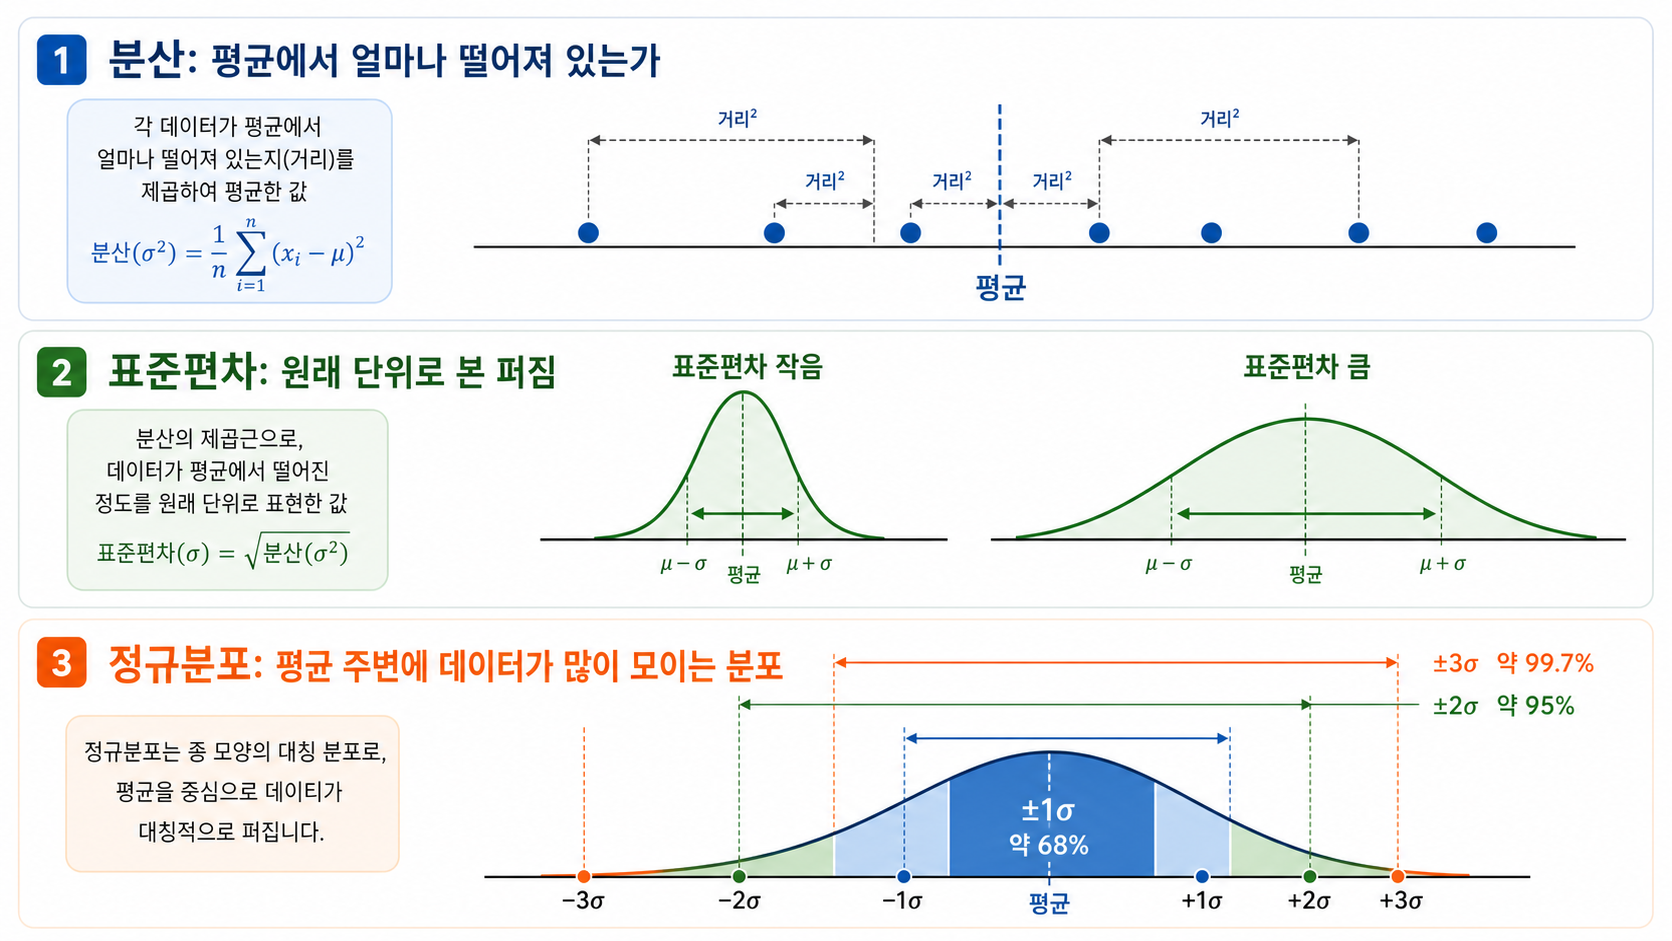

### 1. 모집단과 표본
- 모집단: 알고 싶은 전체 대상임
- 표본: 모집단에서 일부만 뽑은 데이터임
- 전체 조사가 어려울 때 표본으로 모집단 특성을 추정함

### 2. 기술통계와 추론통계
- 기술통계: 현재 가진 데이터를 요약하는 방법임
- 추론통계: 표본으로 모집단을 추정하거나 가설을 검정하는 방법임

### 3. 중심 경향 측도
- 평균: 전체 합을 개수로 나눈 대표값임
- 중앙값: 정렬했을 때 가운데 위치한 값임
- 최빈값: 가장 자주 등장한 값임
- 평균은 이상치 영향이 큼
- 중앙값은 이상치 영향이 상대적으로 작음

```text
점수: 60, 75, 80, 85, 90
평균: 78
중앙값: 80
```

### 4. 산포 측도
- 범위: 최댓값과 최솟값의 차이임
- 분산: 평균에서 떨어진 거리의 제곱 평균임
- 표준편차: 분산의 제곱근임
- 표준편차는 원래 데이터 단위로 해석 가능함
- `np.var()`: 기본적으로 모집단 분산 계산함
- 표본 분산: `ddof=1` 지정함

```python
np.var(scores, ddof=0)  # 모집단 분산
np.var(scores, ddof=1)  # 표본 분산
```

### 5. 확률분포와 정규분포
- 확률: 사건 발생 가능성을 나타내는 값임
- 확률분포: 값이 얼마나 자주 나올 수 있는지 나타낸 것임
- 정규분포: 평균 주변에 데이터가 많이 모이는 종 모양 분포임
- 정규분포의 평균, 중앙값, 최빈값은 같은 위치임
- 대표 규칙: 68-95-99.7 규칙임


## 수업용 직관 예시
- 평균, 중앙값, 분산, 표준편차를 한 번에 설명하기 위한 예시임
- 이상치가 있으면 평균이 크게 흔들릴 수 있음
- 평균이 같아도 데이터의 퍼짐은 다를 수 있음
- 퍼짐을 숫자로 표현한 값이 분산과 표준편차임


In [1]:
import numpy as np

In [3]:
# 평균과 중앙값
# - 중앙값을 사용하는 경우 : 데이터 중 이상치가 존재할 때
scores1 = np.array([70, 75, 80, 85, 90])
scores2 = np.array([70, 75, 80, 85, 300])

print("scores1 평균: ", scores1.mean())
print("scores1 중앙값: ", np.median(scores1))  # numpy 중앙값 함수

print("scores2 평균: ", scores2.mean())
print("scores2 중앙값: ", np.median(scores2))  # numpy 중앙값 함수


scores1 평균:  80.0
scores1 중앙값:  80.0
scores2 평균:  122.0
scores2 중앙값:  80.0


In [5]:
# 분산과 표준편차
class_a = np.array([78, 79, 80, 81, 82])
class_b = np.array([50, 65, 80, 95, 110])

print("a반 평균: ", np.mean(class_a))
print("a반 분산: ", np.var(class_a))
print("a반 표준편차: ", np.std(class_a))
print()
print("b반 평균: ", np.mean(class_b))
print("b반 분산: ", np.var(class_b))
print("b반 표준편차: ", np.std(class_b))


a반 평균:  80.0
a반 분산:  2.0
a반 표준편차:  1.4142135623730951

b반 평균:  80.0
b반 분산:  450.0
b반 표준편차:  21.213203435596427


## 중심 경향 측도
- 데이터의 대표값을 보는 지표임
- 평균, 중앙값, 최빈값 포함함


In [6]:
scores = np.array([85, 90, 92, 88, 90, 75, 88, 95, 92, 85, 80, 95, 100, 92, 85])

In [13]:
# 평균
print("scores 평균: ", np.mean(scores))
print("scores 중앙값: ", np.median(scores))    # 정렬 후 중앙값

# 중복값 제거 - np.unique()
print("scores 중복값 제거: ", np.unique(scores))

# 최빈값: 가장 자주 등장하는 값
# -> np.unique(ndarray, return_counts=True)
# return_counts=True 옵션: 중복을 제거하면서 같은 값이 몇개 있는지 카운트해서 반환
values, counts = np.unique(scores, return_counts=True)
print(values)
print(counts)

max_count = np.max(counts)  # 3
print("max_count: ", max_count)
print(counts == max_count)

# 중복 제거된 배열에서 최빈값을 가진 수만 찾기
vals = values[counts == max_count]
print("최빈값: ", vals)




scores 평균:  88.8
scores 중앙값:  90.0
scores 중복값 제거:  [ 75  80  85  88  90  92  95 100]
[ 75  80  85  88  90  92  95 100]
[1 1 3 2 2 3 2 1]
max_count:  3
[False False  True False False  True False False]
최빈값:  [85 92]


In [14]:
# defaultdict는 없는 키를 처음 만났을 때 기본값을 자동으로 만들어줌.
# 여기서는 점수를 key로, 등장 횟수를 value로 누적한다.

# 최빈값 (collections.defaultdict)
from collections import defaultdict

# defaultdict: 기본값을 제공하는 dict
counts_dict = defaultdict(int) # int기본값(0) 사용
print("counts_dict:", counts_dict)

for score in scores:
    # 해당키값에 대한 선언을 생략 가능
    counts_dict[score] += 1

print("counts_dict:", counts_dict)

max_count = np.max(list(counts_dict.values()))
print(f'최대빈도수: {max_count}')

vals = [key for key in counts_dict if counts_dict[key] == max_count]
print(f'최빈값: {vals}')

counts_dict: defaultdict(<class 'int'>, {})
counts_dict: defaultdict(<class 'int'>, {np.int64(85): 3, np.int64(90): 2, np.int64(92): 3, np.int64(88): 2, np.int64(75): 1, np.int64(95): 2, np.int64(80): 1, np.int64(100): 1})
최대빈도수: 3
최빈값: [np.int64(85), np.int64(92)]


## 산포 측도
- 데이터가 대표값 주변에 얼마나 퍼져 있는지 보는 지표임

### 분산
- 평균에서 떨어진 거리의 제곱 평균임
- 편차를 그냥 더하면 양수/음수가 상쇄될 수 있음
- 제곱을 사용해 퍼짐의 크기를 계산함
- 단위가 제곱되어 직관적 해석은 어려움

**계산 순서**
1. 평균을 구함
2. 각 값에서 평균을 뺌
3. 뺀 값을 제곱함
4. 제곱값들의 평균을 구함

### 표준편차
- 분산에 제곱근을 씌운 값임
- 원래 데이터와 같은 단위로 해석 가능함
- 분산보다 직관적임

```text
표준편차 = √분산
```

### 모집단 분산과 표본 분산
| 구분 | NumPy 코드 | 나누는 값 | 수업용 해석 |
|---|---|---:|---|
| 모집단 분산 | `np.var(scores, ddof=0)` | `n` | 전체 데이터를 모두 가진 경우임 |
| 표본 분산 | `np.var(scores, ddof=1)` | `n - 1` | 일부 표본으로 전체를 추정하는 경우임 |

- `ddof`: Delta Degrees of Freedom의 약자임
- NumPy는 `n - ddof`로 나누어 분산 계산함

**공식 표현**
- 모집단 분산 = `Σ(값 - 모집단평균)² / N`임
- 표본 분산 = `Σ(값 - 표본평균)² / (n - 1)`임


In [18]:
# 분산(Variance)
# - 분산 = (값 - 평균)^2 한 값들의 평균
mean_score = np.mean(scores)
a = scores - mean_score
# print(a)
b = a ** 2
# print(b)

print("평균: ", mean_score)
print("편차: ", a)
print("편차 제곱:", b)
print("분산: ", np.mean(b))  # 편차 제곱의 평균
print("표준편차: ", np.sqrt(np.mean(b)))

평균:  88.8
편차:  [ -3.8   1.2   3.2  -0.8   1.2 -13.8  -0.8   6.2   3.2  -3.8  -8.8   6.2
  11.2   3.2  -3.8]
편차 제곱: [ 14.44   1.44  10.24   0.64   1.44 190.44   0.64  38.44  10.24  14.44
  77.44  38.44 125.44  10.24  14.44]
분산:  36.559999999999995
표준편차:  6.046486583132389


In [20]:
# numpy를 이용한 분산, 표준편차
print("분산: ", np.var(scores, ddof=0))
print("표준 편차: ", np.std(scores, ddof=0))

분산:  36.559999999999995
표준 편차:  6.046486583132389


In [21]:
# ddof = 1
# 표본에 대한 분산, 표준편차
print("분산: ", np.var(scores, ddof=1))
print("표준 편차: ", np.std(scores, ddof=1))

분산:  39.17142857142857
표준 편차:  6.258708219067939


## 확률분포
- 어떤 값이 얼마나 자주 나올 수 있는지 나타낸 것임

### `np.random`
- 다양한 분포에서 난수를 만들 때 사용하는 NumPy 모듈임
- `np.random.normal(loc, scale, size)`: 정규분포 난수 생성함
- `np.random.randn(...)`: 표준정규분포 난수 생성함
- `np.random.randint(low, high, size)`: 정수 난수 생성함
- `np.random.rand(...)`: 0 이상 1 미만 균등분포 실수 난수 생성함
- 분포 학습 시 숫자와 그래프를 함께 확인하는 것이 좋음


In [2]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.3 MB 3.5 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.3 MB 5.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 5.9 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.3 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 7.5 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 22.1 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ------------- ----

In [3]:
# 조금 자세히: Matplotlib은 기본 폰트가 한글을 지원하지 않아 경고가 날 수 있습니다.
# 운영체제별 후보 폰트 중 실제 설치된 폰트를 찾아 그래프 제목/축 라벨이 깨지지 않게 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Matplotlib 기본 폰트(DejaVu Sans)는 한글 글리프가 없어 경고가 날 수 있습니다.
# 운영체제별로 사용 가능한 한글 폰트를 찾아 설정합니다.
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

available_fonts = {font.name for font in fm.fontManager.ttflist}
system_name = platform.system()
selected_font = None

for font_name in font_candidates.get(system_name, []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. NanumGothic 또는 Noto Sans KR 설치가 필요할 수 있습니다.")

# 마이너스 기호가 깨지는 문제 방지
plt.rcParams["axes.unicode_minus"] = False

설정된 한글 폰트: Malgun Gothic


#### 정규분포
- 평균 주변에 데이터가 많이 모이는 분포임
- 평균에서 멀어질수록 빈도가 줄어듦
- 종 모양 분포임


In [5]:
# np.random.normal(loc, scale, size)
# - loc : 평균값
# - scale : 표준편차
# - size : 생성할 난수의 개수
# - 평균값(loc)으로 중심 위치를 잡고,
#   표준편차(scale)로 값들이 퍼지는 범위를 조절
#   그러면 생성한 난수들이 표준편차 범위 내에서 생성

# 평균 10, 표준편차 1, 10행 10열
arr = np.random.normal(10, 1, (10, 10))
print(arr)

print("평균: ", np.mean(arr))
print("분산: ", np.var(arr, ddof=0))
print("표준편차: ", np.std(arr, ddof=0))

[[ 9.92432732 10.88768106  9.25539942  9.40459514  9.70396477  9.84264886
  10.1571944   9.86401139  9.79148291 10.14193111]
 [ 9.20719029  7.94777395 10.38839677  8.36952026 11.00285604  9.67590556
  10.71108687 11.47635032  9.35977687 12.07539416]
 [ 9.04571103 11.12506885  8.67685022 10.82216384  9.79230174 10.08062086
   8.81176936  8.18863725 10.41945803 12.72115191]
 [11.01771769  9.29732608 10.26174687  9.86401466 12.14147425  9.49235092
  10.84373091 10.43096111  9.18498317  9.52864294]
 [10.36406395 10.21848076 10.43062698  7.78585803 10.77632386  9.8479209
  10.03844644 10.4146708  10.22234395 10.18713313]
 [ 8.6751745   9.72076153  7.90159838 10.3584871   9.02477552  8.82109085
   9.87720859 10.39575795  8.06386447 11.20259731]
 [10.59233262 10.61430012 11.47539164  8.77740011  8.9363983   8.08211781
  11.49912519  9.46518304  9.90802367 10.05482765]
 [10.18817149  9.86717229 10.89543865 11.48359165  8.34477783 10.84582023
   8.61619449  9.88444599  9.73189639 10.42955228]
 

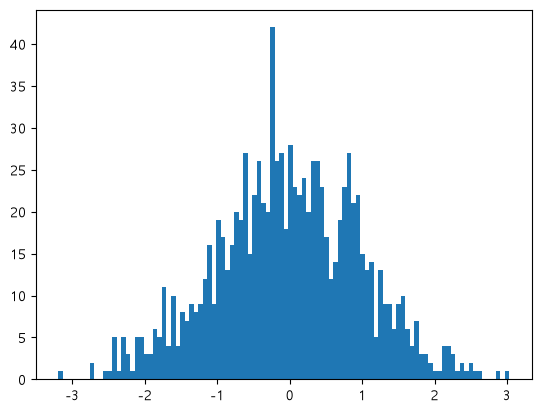

In [8]:
# 히스토그램을 이용한 시각화
# -> 정규분포 데이터가 평균 근처에 몰려있는 것을 확인
arr = np.random.normal(loc=0, scale=1, size=1000)
plt.hist(arr, bins=100)
plt.show()

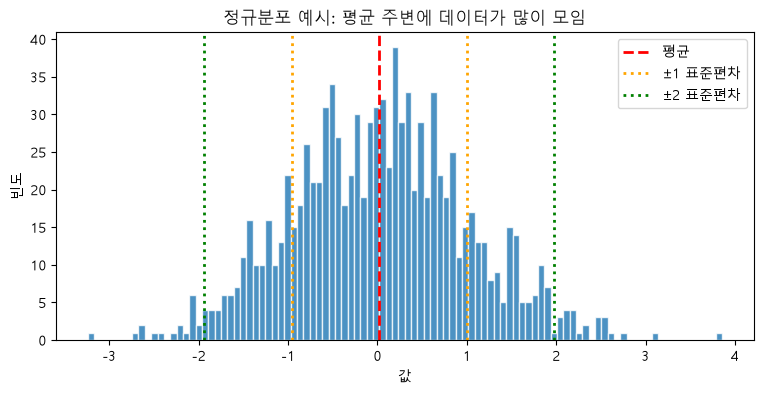

In [9]:
np.random.seed(42)
arr = np.random.normal(loc=0, scale=1, size=1000)

mean = np.mean(arr)
std = np.std(arr)

plt.figure(figsize=(9, 4))
plt.hist(arr, bins=100, edgecolor="white", alpha=0.8)
plt.axvline(mean, color="red", linestyle="--", linewidth=2, label="평균")
plt.axvline(mean - std, color="orange", linestyle=":", linewidth=2, label="±1 표준편차")
plt.axvline(mean + std, color="orange", linestyle=":", linewidth=2)
plt.axvline(mean - 2 * std, color="green", linestyle=":", linewidth=2, label="±2 표준편차")
plt.axvline(mean + 2 * std, color="green", linestyle=":", linewidth=2)
plt.title("정규분포 예시: 평균 주변에 데이터가 많이 모임")
plt.xlabel("값")
plt.ylabel("빈도")
plt.legend()
plt.show()

In [13]:
# np.random.randn(size) : 평균 0, 표준편차 1 범위의 난수를 size개 생성

arr = np.random.randn(5,20)
arr


array([[-0.37912774, -0.20358036, -0.58168091, -1.01475673, -0.64927755,
        -1.22394027,  0.03408347, -0.76997323,  0.23378591, -1.55589565,
         0.33088023,  0.83352896, -1.99373564,  0.37405657,  1.22766899,
        -1.20964102,  1.67257239,  0.41901901, -0.70501186, -0.05576908],
       [ 0.55832691,  0.07600539,  0.53875599, -0.92067359,  0.16936082,
        -1.4137145 , -0.11122606, -0.90390764, -0.73552994,  1.23609318,
         1.09131012,  0.60913812, -1.09231276, -0.31640845,  1.2130977 ,
         0.14171691,  2.31932954,  0.39331784,  0.19204912, -0.30911646],
       [ 0.1335409 , -0.15246984,  0.70810868,  0.95670232, -0.78598946,
        -1.33123295, -1.83620537,  0.50799133, -1.10336661, -2.15289059,
         0.3885786 ,  2.49299952, -0.00607091,  0.83849077,  0.08182936,
        -0.09888965,  0.91907648, -0.29027454,  0.26739231,  0.32169781],
       [-0.66809045,  0.99204235, -0.17495976, -0.75574516,  0.53650984,
        -0.89846798,  0.02818116, -0.009119  ,  

#### 균등분포
- 각 값 또는 구간이 비슷한 확률로 나오는 분포임
- 특정 구간에 치우침이 적음


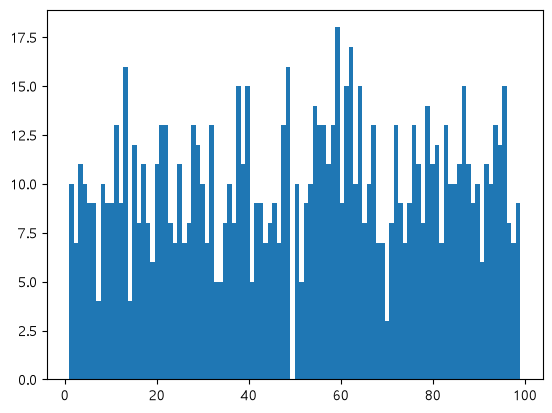

In [18]:
# np.random.randint(low, high, size)
arr = np.random.randint(1, 100, 1000)
# arr
plt.hist(arr, bins=100)
plt.show()

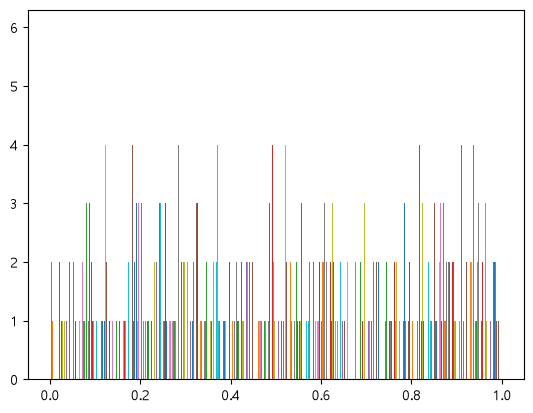

In [20]:
# np.random.rand(size) : 0 ~ 1 사이 균등분포 난수 생성
arr = np.random.rand(100, 100)
plt.hist(arr, bins=100)
plt.show()

#### 그외
- `seed`: 난수 결과 재현을 위한 시작값임
- `choice`: 배열에서 무작위 선택하는 함수임
- `replace=True`: 복원추출임
- `replace=False`: 비복원추출임


In [24]:
# seed: 난수 생성 결과를 재현하기 위한 시작 값
np.random.seed(123)
random_values = np.random.rand(2, 3)
print(random_values)

[[0.69646919 0.28613933 0.22685145]
 [0.55131477 0.71946897 0.42310646]]


In [28]:
# np.random.choice(ndarray) : 배열 내에서 무작위 값 추출
arr = np.array([10, 3, 5, 7, 8, 9])
print("1개 무작위 추출: ", np.random.choice(arr))

# np.random.choice(ndarray, size, replace)
# - 배열 ㅐ네서 무작위 값을 size 만큼 추출
# - replace = True -> 복원추출(기본값)
# - replace = False -> 비복원추출
print("3개 무작위 추출: ", np.random.choice(arr, size=3))
print("3개 무작위 추출: ", np.random.choice(arr, size=3, replace=False))   # 복원추출

1개 무작위 추출:  8
3개 무작위 추출:  [10 10  8]
3개 무작위 추출:  [ 8  9 10]


In [47]:
# np.random.choice(ndarray, p)
# p인자 : 각 값이 선택될 확률을 직접 지정
# 확률 목록의 합은 1이 되어야 하며, 확률 요소의 개수는 ndarray와 같아야 함
probs = [0.8, 0.05, 0.05, 0.05, 0.025, 0.025]
print(np.random.choice(arr,  p=probs))

10
